# 01 — Zero-Shot vs Few-Shot JSON Classification

## Goal

Classify 500 stratified Yelp reviews (100 per star class) into 1–5 stars, with strict JSON output `{stars, explanation}`.

Compare two prompting strategies across **three classifier families** to pick the best model for downstream tasks:

| Family | Model |
|---|---|
| OpenAI | `openai/gpt-5-nano` |
| DeepSeek | `deepseek/deepseek-v3.2` |
| Google | `google/gemini-2.0-flash` |

Strategies:
- **Zero-shot**: instruction + review, no examples.
- **Few-shot**: 5 labeled Yelp reviews (one per class) prepended before the target.

## Metrics

| | Measures |
|---|---|
| Accuracy | exact match with human label |
| Macro-F1 | class-balanced quality (prevents majority cheating) |
| MAE | ordinal error — off-by-1 ≠ off-by-4 |
| Compliance | valid Pydantic JSON rate |

## Selection rule

Winner = highest macro-F1 × lowest MAE. Locked into `lib/config.ACTIVE_CLASSIFIER` for all downstream notebooks.

In [1]:
import sys
sys.path.insert(0, '..')

import asyncio, json, time
from pathlib import Path
import pandas as pd

from lib.config import CLASSIFIER_CANDIDATES
from lib.gateway import classify_json
from lib.schemas import StarsOnly
from lib.prompts import CLASSIFIER_SYSTEM, zero_shot, few_shot
from lib.datasets import read_jsonl, class_dist
from lib.concurrency import gather_limited
from lib.metrics import Prediction, report, fmt
from lib.plots import confusion_heatmap, bar_compare

EVAL_PATH = '../data/yelp_eval.jsonl'
FEWSHOT_PATH = '../data/yelp_fewshot.jsonl'
CLASSES = [1, 2, 3, 4, 5]

eval_set = read_jsonl(EVAL_PATH)
fewshot  = read_jsonl(FEWSHOT_PATH)
print(f'eval n={len(eval_set)}  dist={class_dist(eval_set)}')
print(f'fewshot n={len(fewshot)}  dist={class_dist(fewshot)}')

eval n=500  dist={1: 100, 2: 100, 3: 100, 4: 100, 5: 100}
fewshot n=5  dist={1: 1, 2: 1, 3: 1, 4: 1, 5: 1}


## Inspect prompts

Render the exact prompts that will be sent, on the first eval row.

In [2]:
sample = eval_set[0]
print('--- sample review (truth =', sample['stars'], '★) ---')
print(sample['text'][:300])
print()
print('--- zero-shot prompt ---')
print(zero_shot(sample['text'])[:400])
print()
print('--- few-shot prompt (truncated) ---')
print(few_shot(sample['text'], fewshot)[:600])

--- sample review (truth = 4 ★) ---
I really enjoy what the Hale Center Theater brings.  I have seen some great performances and have been surprised at how well the scenary is done and the actors perform.  It is definitely worth it.  So happy Gilbert offers this.

--- zero-shot prompt ---
Classify this review (1-5 stars) and give a short explanation.

Review: I really enjoy what the Hale Center Theater brings.  I have seen some great performances and have been surprised at how well the scenary is done and the actors perform.  It is definitely worth it.  So happy Gilbert offers this.

--- few-shot prompt (truncated) ---
Example 1:
Review: Loved this place! I went here with my boyfriend for our first time and we just loved it here!
Output: {"stars": 4, "explanation": "Mostly positive with some minor complaints."}

Example 2:
Review: I never met a discount store I didn't like....until now.\n\nI'm a big Ross/Marshall's/TJ Maxx shopper but I have to say -- there is never anything good in he

## Run batch — 3 classifiers × 2 strategies × 500 rows

Concurrency 30, temp=0, cached. Re-runs are near-instant after first.

In [3]:
async def predict_one(model: str, strategy: str, row: dict) -> Prediction:
    prompt = zero_shot(row['text']) if strategy == 'zero' else few_shot(row['text'], fewshot)
    obj, meta = await classify_json(StarsOnly, CLASSIFIER_SYSTEM, prompt, model=model)
    return Prediction(pred=obj.stars if obj else None, truth=row['stars'], extra={'error': meta.get('error')})

all_results: dict[str, dict[str, list[Prediction]]] = {}
for model in CLASSIFIER_CANDIDATES:
    all_results[model] = {}
    for strat in ('zero', 'few'):
        desc = f'{model.split("/")[-1]} {strat}'
        t0 = time.time()
        preds = await gather_limited(eval_set, lambda r, m=model, s=strat: predict_one(m, s, r), concurrency=30, desc=desc)
        secs = time.time() - t0
        all_results[model][strat] = preds
        r = report(preds, CLASSES)
        print(f'{desc:50s} acc={r["accuracy"]*100:.1f}%  F1={r["macro_f1"]:.3f}  MAE={r["mae"]:.3f}  compl={r["compliance"]*100:.1f}%  t={secs:.1f}s')

gpt-5-nano zero:   0%|          | 0/500 [00:00<?, ?it/s]

gpt-5-nano zero:   0%|          | 1/500 [00:02<22:25,  2.70s/it]

gpt-5-nano zero:   0%|          | 2/500 [00:03<12:04,  1.46s/it]

gpt-5-nano zero:   1%|          | 3/500 [00:03<07:04,  1.17it/s]

gpt-5-nano zero:   1%|          | 4/500 [00:03<04:48,  1.72it/s]

...

gemini-2.0-flash few:  97%|█████████▋| 486/500 [00:16<00:00, 28.54it/s]

gemini-2.0-flash few:  99%|█████████▊| 493/500 [00:16<00:00, 34.76it/s]

gemini-2.0-flash few: 100%|█████████▉| 498/500 [00:16<00:00, 32.98it/s]

gemini-2.0-flash few: 100%|██████████| 500/500 [00:16<00:00, 29.77it/s]

gemini-2.0-flash few                               acc=66.0%  F1=0.656  MAE=0.354  compl=100.0%  t=16.8s


## Summary table

In [4]:
rows = []
for model, by_strat in all_results.items():
    for strat, preds in by_strat.items():
        r = report(preds, CLASSES)
        rows.append({
            'model': model,
            'strategy': strat,
            'compliance': round(r['compliance'] * 100, 1),
            'accuracy':   round(r['accuracy']   * 100, 1),
            'macro_f1':   round(r['macro_f1'],   3),
            'mae':        round(r['mae'],        3),
        })
df = pd.DataFrame(rows)
df.sort_values(['strategy', 'macro_f1'], ascending=[True, False])

,model,strategy,compliance,accuracy,macro_f1,mae
3,deepseek/deepseek-v3.2,few,100.0,66.0,0.662,0.350
5,google/gemini-2.0-flash,few,100.0,66.0,0.656,0.354
1,openai/gpt-5-nano,few,100.0,58.6,0.572,0.442
4,google/gemini-2.0-flash,zero,100.0,63.4,0.627,0.384
2,deepseek/deepseek-v3.2,zero,99.6,62.4,0.617,0.390
0,openai/gpt-5-nano,zero,100.0,57.2,0.544,0.456


## Confusion matrices — few-shot (best case) per model

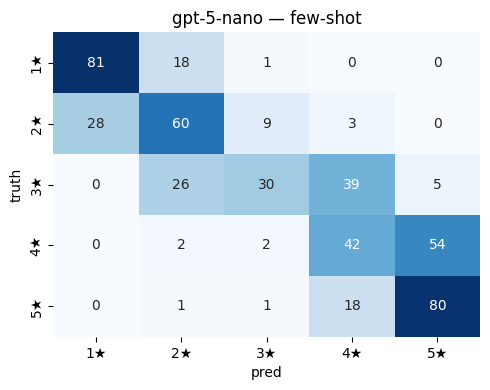

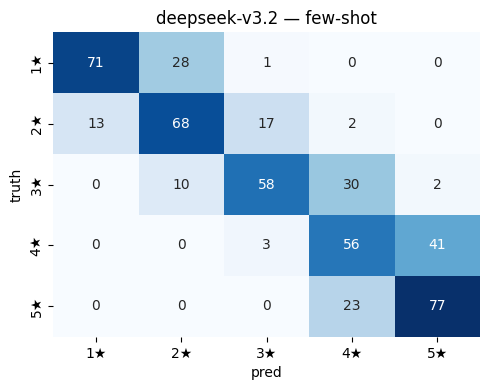

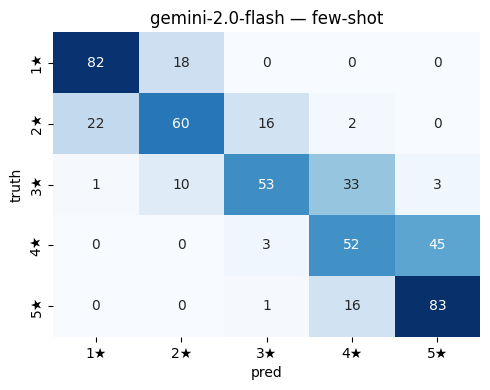

In [5]:
import matplotlib.pyplot as plt
Path('../results/plots').mkdir(parents=True, exist_ok=True)
for model in CLASSIFIER_CANDIDATES:
    r = report(all_results[model]['few'], CLASSES)
    tag = model.split('/')[-1]
    confusion_heatmap(r['confusion'], CLASSES, title=f'{tag} — few-shot', save=f'../results/plots/01_conf_{tag}_few.png')
    plt.show()

## Accuracy comparison bar chart

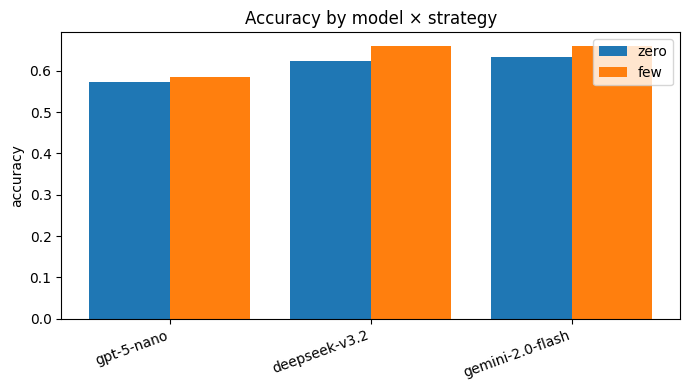

In [6]:
acc_data = {m: {s: report(preds, CLASSES)['accuracy'] for s, preds in v.items()} for m, v in all_results.items()}
bar_compare(acc_data, 'accuracy', title='Accuracy by model × strategy', save='../results/plots/01_accuracy_bar.png')
plt.show()

## Error analysis — hardest misses

Reviews where all three models got it wrong, sorted by largest absolute error.

In [7]:
hard = []
for i, row in enumerate(eval_set):
    preds = {m: all_results[m]['few'][i].pred for m in CLASSIFIER_CANDIDATES}
    if all(p is not None and p != row['stars'] for p in preds.values()):
        err = sum(abs(p - row['stars']) for p in preds.values())
        hard.append((err, i, row['stars'], preds, row['text'][:200]))
hard.sort(reverse=True)
for err, i, truth, preds, text in hard[:5]:
    print(f'[row {i}]  truth={truth}★  preds={preds}  sum_err={err}')
    print('  ', text.replace(chr(10), ' '))
    print()

[row 473]  truth=3★  preds={'openai/gpt-5-nano': 5, 'deepseek/deepseek-v3.2': 5, 'google/gemini-2.0-flash': 5}  sum_err=6
   Best hot and sour soup I've ever had!\n\nTake out! It's a hole in the wall. Family owned and ran, great people! I've been going here since a kid service and quality are consistent! Make sure you call 

[row 463]  truth=2★  preds={'openai/gpt-5-nano': 4, 'deepseek/deepseek-v3.2': 4, 'google/gemini-2.0-flash': 4}  sum_err=6
   The parking is not that easy here, even if you arrived early.  I think that we ended up in someone's backyard lot.  It's not that close to the freeways.  But, catching the W.Sox v. Cubs game here for 

[row 447]  truth=3★  preds={'openai/gpt-5-nano': 5, 'deepseek/deepseek-v3.2': 5, 'google/gemini-2.0-flash': 5}  sum_err=6
   You like steak?  You like titties?  Come to Treasures for both!\n\nFood:  Fantastic!  Treasures was classy and their steaks were on par with some of the high end steakhouses that I had in the past.  S

[row 442]  truth=3★

## Pick winner and persist

Score = `macro_f1 / (mae + 0.01)` on few-shot runs.

In [8]:
scores = {}
for model in CLASSIFIER_CANDIDATES:
    r = report(all_results[model]['few'], CLASSES)
    scores[model] = r['macro_f1'] / (r['mae'] + 0.01)
    print(f'{model:30s} composite={scores[model]:.3f}')

winner = max(scores, key=scores.get)
print(f'\nWINNER: {winner}')

openai/gpt-5-nano              composite=1.265
deepseek/deepseek-v3.2         composite=1.839
google/gemini-2.0-flash        composite=1.803

WINNER: deepseek/deepseek-v3.2


In [9]:
out = {}
for model, by_strat in all_results.items():
    out[model] = {s: report(preds, CLASSES) for s, preds in by_strat.items()}
out['winner'] = winner
Path('../results').mkdir(exist_ok=True)
Path('../results/01_json_prompt.json').write_text(json.dumps(out, indent=2))
print('wrote results/01_json_prompt.json')
print('\nTo lock the winner, set ACTIVE_CLASSIFIER in lib/config.py to:')
print(f'  "{winner}"')

wrote results/01_json_prompt.json

To lock the winner, set ACTIVE_CLASSIFIER in lib/config.py to:
  "deepseek/deepseek-v3.2"


## Findings (fill in after run)

- Best overall family: *TBD after execution*
- Few-shot vs zero delta per model
- Middle classes (3★, 4★) remain hardest
- JSON compliance near 100% regardless of model — Pydantic schema does heavy lifting

Next: `02_cot_vs_direct.ipynb` (Task 2).